Education---Economy Analysis:

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import seaborn

Importing CSV Data

In [2]:
url = r'C:\Users\Josh\OneDrive\Documents\Downloads\education-economy-data.csv'

In [3]:
economy = pd.read_csv(url)
#(education)

In [4]:
economy.head()

,Country,Literacy Rate,Physician Density,GDP (Current USD),GDP Growth (% Annual),GDP per Capita (Current USD),GDP per Capita Category,Unemployment Rate (%),Continent
0,Afghanistan,43.0,0.28,1.723305e+10,2.710887,415.707417,Very Low,13.991,Asia
1,Albania,98.1,1.20,2.354718e+10,3.936625,8575.171134,Mid,10.108,Europe
2,Algeria,81.4,1.72,2.476260e+11,4.100000,5364.027950,Low,11.701,Africa
3,Andorra,100.0,3.33,3.785067e+09,2.583555,46812.448450,High,3.700,Europe
4,Angola,71.1,0.21,8.482465e+10,1.001289,2308.159767,Low,14.537,Africa


Data Exploration

In [5]:
economy.info()

# Checking for any odd dtype 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       191 non-null    object 
 1   Literacy Rate                 191 non-null    float64
 2   Physician Density             191 non-null    float64
 3   GDP (Current USD)             191 non-null    float64
 4   GDP Growth (% Annual)         191 non-null    float64
 5   GDP per Capita (Current USD)  191 non-null    float64
 6   GDP per Capita Category       191 non-null    object 
 7   Unemployment Rate (%)         191 non-null    float64
 8   Continent                     191 non-null    object 
dtypes: float64(6), object(3)
memory usage: 13.6+ KB


In [6]:
economy.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
186    False
187    False
188    False
189    False
190    False
Length: 191, dtype: bool

📈 Business Questions

A. Education Impact Analysis

1️⃣ What is the global literacy distribution?

2️⃣ Which continents have the highest/lowest literacy rates?

3️⃣ Does a higher literacy rate correlate with higher GDP per capita?

4️⃣ How does literacy relate to unemployment across countries?


B. Economic Strength Comparisons

5️⃣ Which continents are most/least economically prosperous?

6️⃣ What countries are outliers (high education but low income)?

7️⃣ How do GDP Growth rates compare across education categories?


C. Healthcare Professional Proxy

8️⃣ Is physician density higher in more educated countries?

9️⃣ Does lower physician density correlate with lower literacy or wealth?


D. Priority Regions for Intervention

🔟 Which countries need urgent support?

Low literacy + low GDP per capita + high unemployment

 (A) Education Impact Analysis 


In [7]:
economy['Literacy Rate'].head()

0     43.0
1     98.1
2     81.4
3    100.0
4     71.1
Name: Literacy Rate, dtype: float64


                             1️⃣ What is the global literacy distribution?


In [8]:
economy[['Literacy Rate', 'Country']].head

<bound method NDFrame.head of      Literacy Rate      Country
0             43.0  Afghanistan
1             98.1      Albania
2             81.4      Algeria
3            100.0      Andorra
4             71.1       Angola
..             ...          ...
186           97.1    Venezuela
187           95.4      Vietnam
188           54.1        Yemen
189           87.4       Zambia
190           89.0     Zimbabwe

[191 rows x 2 columns]>

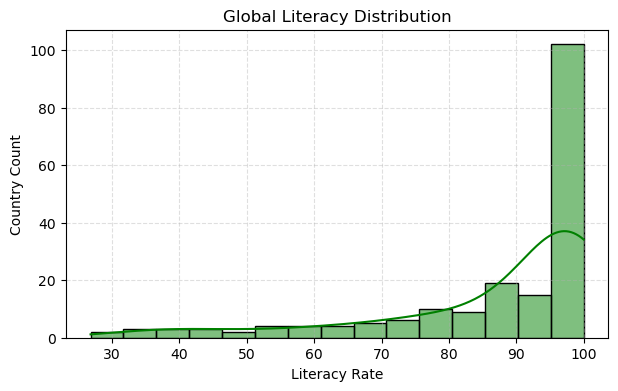

In [9]:


import matplotlib.pyplot as plt
import seaborn as sns

print()
plt.figure(figsize=(7, 4))

# Use sns.histplot for distributions
sns.histplot(data=economy, 
             x='Literacy Rate', 
             kde=True,      # This works here!
             bins=15,       # This works here!
             color='green', 
             edgecolor='black')

plt.title('Global Literacy Distribution', fontsize=12, color='black')
plt.xlabel('Literacy Rate', fontsize=10)
plt.ylabel('Country Count', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()


In [10]:
import pandas as pd

# Create bins (intervals of 10)
bins = [0, 40, 60, 80, 90, 100]
labels = ['0–40', '41–60', '61–80', '81–90', '91–100']

distribution = pd.cut(economy['Literacy Rate'], bins=bins, labels=labels).value_counts().sort_index()
print(distribution)


Literacy Rate
0–40        7
41–60      12
61–80      25
81–90      29
91–100    118
Name: count, dtype: int64



                      2️⃣ Which continents have the highest/lowest literacy rates?


In [11]:
#Columns
economy[['Literacy Rate', 'Continent']].head()

,Literacy Rate,Continent
0,43.0,Asia
1,98.1,Europe
2,81.4,Africa
3,100.0,Europe
4,71.1,Africa


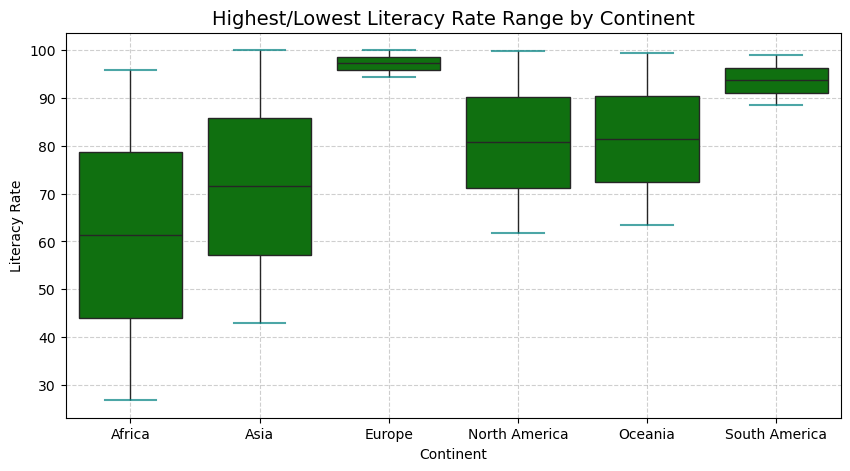

In [12]:
# 1. Reset the index so 'Continent' becomes a column again
high_low = economy.groupby('Continent')['Literacy Rate'].agg(['min', 'max']).reset_index()

# 2. "Melt" the data so 'min' and 'max' are in one column called 'Rate'
# This creates the "Range" you're looking for
high_low_melted = high_low.melt(id_vars='Continent', value_vars=['min', 'max'], 
                                var_name='Stat', value_name='Literacy_Rate')

# 3. Now Plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=high_low_melted, 
            x='Continent', 
            y='Literacy_Rate', 
            color='green',
            capprops=dict(linestyle='-', linewidth=1.5, color='teal', alpha=0.7))

plt.title('Highest/Lowest Literacy Rate Range by Continent', fontsize=14)
plt.xlabel('Continent', fontsize=10)
plt.ylabel('Literacy Rate', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


                 3️⃣ Does a higher literacy rate correlate with higher GDP per capita?


Correlation between Literacy Rate and GDP per Capita: 0.366


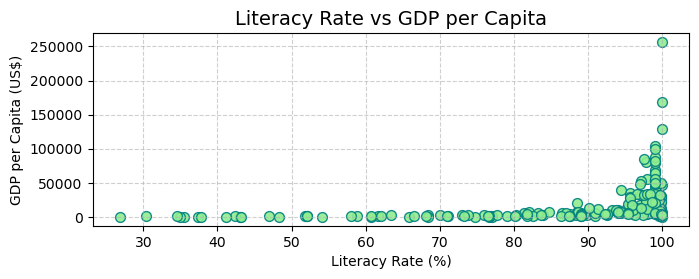

Higher Literacy Rates Connect to Higher GDP per Capita: Countries with higher literacy rates tend to have higher GDP per capita.
Education Impacts the economy positively


In [13]:
# Check correlation between Literacy Rate and GDP per Capita
corr = economy['Literacy Rate'].corr(economy['GDP per Capita (Current USD)'])
print(f"Correlation between Literacy Rate and GDP per Capita: {corr:.3f}")

# Visualization
plt.figure(figsize=(7.7,2.5))
plt.scatter(
    economy['Literacy Rate'],
    economy['GDP per Capita (Current USD)'],
    alpha=0.9,
    color='lightgreen',
    edgecolor='teal',
    s=50
)
plt.title("Literacy Rate vs GDP per Capita", fontsize=14)
plt.xlabel("Literacy Rate (%)")
plt.ylabel("GDP per Capita (US$)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

print("Higher Literacy Rates Connect to Higher GDP per Capita: Countries with higher literacy rates tend to have higher GDP per capita.")
print("Education Impacts the economy positively")

                4️⃣ How does literacy relate to unemployment across countries?


In [14]:
 economy[['Country', 'Literacy Rate', 'Unemployment Rate (%)']].head()

,Country,Literacy Rate,Unemployment Rate (%)
0,Afghanistan,43.0,13.991
1,Albania,98.1,10.108
2,Algeria,81.4,11.701
3,Andorra,100.0,3.700
4,Angola,71.1,14.537


Correlation between Literacy Rate and GDP per Capita: -0.006


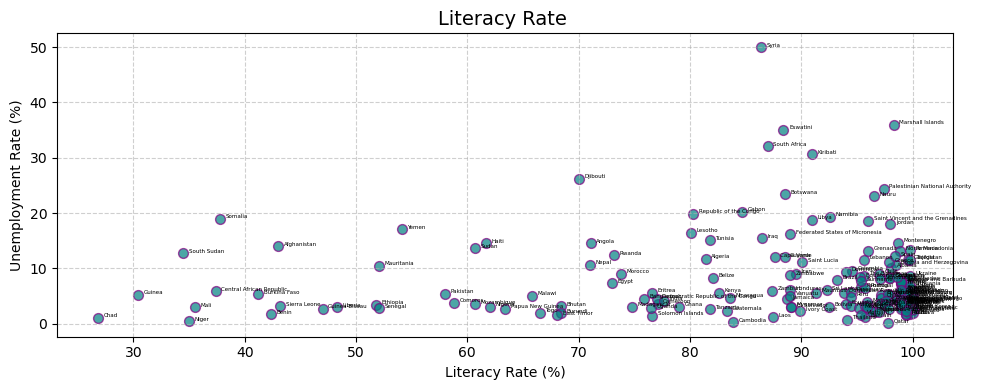

High Literacy Rate = Low Unemployment
High Literacy Rate has reduces unemploymen in most countries.


In [15]:
# How Literacy Rate affects Unemployment in Countries 

import matplotlib.pyplot as plt

# Correlation between Literacy Rate and GDP per Capita
corr = economy['Literacy Rate'].corr(economy['Unemployment Rate (%)'])
print(f"Correlation between Literacy Rate and GDP per Capita: {corr:.3f}")

#Visualiizng Scatter plot

plt.figure(figsize=(10, 4)) 

# 1. Scatter plot
plt.scatter(
    economy['Literacy Rate'], 
    economy['Unemployment Rate (%)'], 
    alpha=0.7, 
    color='teal',
    edgecolors='purple',
    s=50 # Adjusted marker size
)

# 2. Annotations
# Iterated through each country's data to place the label
for i, row in economy.iterrows():
    plt.text(
        x=row['Literacy Rate'] + 0.5, 
        y=row['Unemployment Rate (%)'] + 0.1,
        s=row['Country'], 
        fontsize=4, 
        color='black'
    )

# 3. Labels and Title
plt.title("Literacy Rate ", 
          fontsize=14)
plt.xlabel("Literacy Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() 
plt.show()

print("High Literacy Rate = Low Unemployment")
print("High Literacy Rate has reduces unemploymen in most countries.")

The Scatte pot shows how each continent Literacy Rate, connects to Unemployment


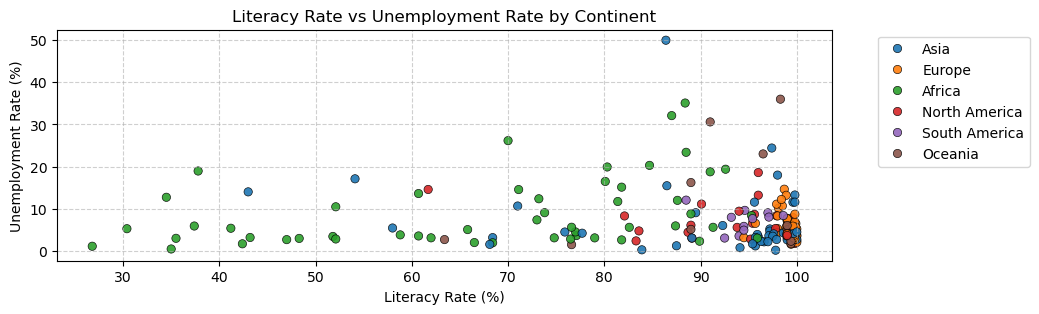

The plot shows some Outliers, like in Asia, Africa and Oceania most countries with high literacy rate, have the highest rate of unemployment, with is unusual.


In [16]:

import seaborn as sns
print("The Scatte pot shows how each continent Literacy Rate, connects to Unemployment")

#Visualization
plt.figure(figsize=(10, 3))
sns.scatterplot(
    data=economy,
    x='Literacy Rate',
    y='Unemployment Rate (%)',
    hue='Continent',
    alpha=0.9,
    edgecolors='black'
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Literacy Rate vs Unemployment Rate by Continent")
plt.xlabel("Literacy Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True, linestyle= '--',alpha= 0.6)
plt.show()

print("The plot shows some Outliers, like in Asia, Africa and Oceania most countries with high literacy rate, have the highest rate of unemployment, with is unusual.")

B. Economic Strength Comparisons

                     5️⃣ Which continents are most/least economically prosperous?

In [17]:
#Relevant columns 
economy[['Continent', 'GDP per Capita (Current USD)']].head()

,Continent,GDP per Capita (Current USD)
0,Asia,415.707417
1,Europe,8575.171134
2,Africa,5364.027950
3,Europe,46812.448450
4,Africa,2308.159767


In [18]:

wowo = economy.groupby('Continent')['GDP per Capita (Current USD)'].mean()

chai = wowo.sort_values(ascending=True)

bar = chai.reset_index()

bar

,Continent,GDP per Capita (Current USD)
0,Africa,2753.761454
1,South America,11265.121583
2,Oceania,13161.836639
3,Asia,14523.358507
4,North America,17661.337151
5,Europe,47412.476414


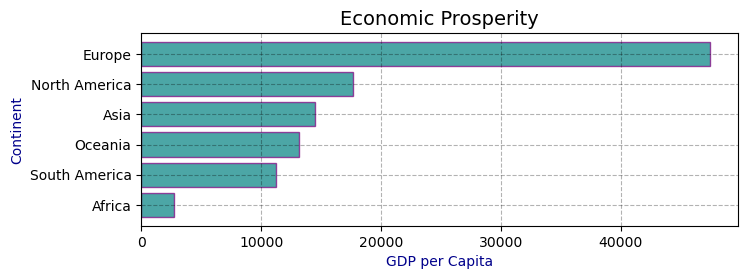

The chart shows that: Europe is the most Economic Prosperous continent. With a GDP of $47,412.476414 marking the highest Globally.
...
The chart shows that: Africa is the least Economic Prosperous continent. With a GDP of $2,753.761454 marking the highest Globally.


In [19]:
#Visualization: Economic Prosperity
plt.figure(figsize=(7.7,2.5))
plt.barh(
    bar['Continent'], 
    bar['GDP per Capita (Current USD)'],
    alpha = 0.7, 
    color='teal', 
    edgecolor='purple'
)

plt.title('Economic Prosperity', 
         fontsize=14)
plt.xlabel('GDP per Capita', 
           color='darkblue', 
          fontsize=10)
plt.ylabel('Continent', 
           color='darkblue',
           fontsize=10)
plt.grid(True, 
         linestyle='--', color='black',
         alpha=0.3)
plt.show()

print("The chart shows that: Europe is the most Economic Prosperous continent. With a GDP of $47,412.476414 marking the highest Globally.")
print("...")
print("The chart shows that: Africa is the least Economic Prosperous continent. With a GDP of $2,753.761454 marking the highest Globally.")

In [20]:
#Relevant Columns
economy[['Country','Literacy Rate', 'GDP per Capita (Current USD)']].head()

,Country,Literacy Rate,GDP per Capita (Current USD)
0,Afghanistan,43.0,415.707417
1,Albania,98.1,8575.171134
2,Algeria,81.4,5364.027950
3,Andorra,100.0,46812.448450
4,Angola,71.1,2308.159767


This Scatter plot shows the Economic Outliers...


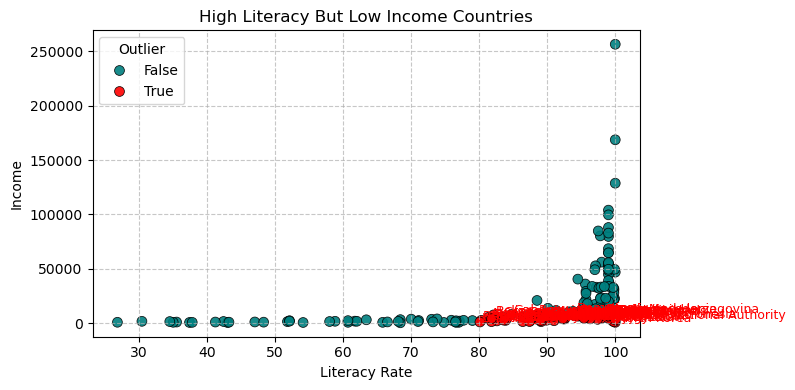

This is a Grouped Scatter plot, to show the Outlying Countries...Countries that have a High level of Education and Literacy Rate, but also have Low Income
The Clusted red are the Outlying countries, Based on the plot
Indicator: The red dots are clusted at the bottom of the Y-axis(Income). And they are packed at top of the X-axis(Literacy Rate)


In [21]:
print("This Scatter plot shows the Economic Outliers...")

high_literacy = economy['Literacy Rate'] >=80
low_economy = economy['GDP per Capita (Current USD)'] <= 10000


economy['Outlier'] = high_literacy & low_economy

#Plot Visual

plt.figure(figsize=(8,4)) 

sns.scatterplot(
    data = economy, 
    x = 'Literacy Rate', 
    y = 'GDP per Capita (Current USD)',
    hue = 'Outlier',
    palette = {True : 'red', 
               False : 'teal'}, 
    s=50, 
    alpha=0.9,
    edgecolor = 'black'
)

#Adding Labels for Outlier Countries

for i, row in economy[economy['Outlier'] == True].iterrows():
    plt.text(
       x= row['Literacy Rate'] + 0.3,
       y= row['GDP per Capita (Current USD)'] + 300,
       s= row['Country'], 
        fontsize = 9, 
        color = 'red'
    )

plt.title('High Literacy But Low Income Countries')
plt.xlabel('Literacy Rate')
plt.ylabel('Income')
plt.grid(True, 
         linestyle='--',
        alpha=0.7)
plt.tight_layout()

plt.show()

print("This is a Grouped Scatter plot, to show the Outlying Countries...Countries that have a High level of Education and Literacy Rate, but also have Low Income")
print("The Clusted red are the Outlying countries, Based on the plot")
print("Indicator: The red dots are clusted at the bottom of the Y-axis(Income). And they are packed at top of the X-axis(Literacy Rate)")

In [22]:
economy[['GDP Growth (% Annual)', 'Literacy Rate' ]].head()

,GDP Growth (% Annual),Literacy Rate
0,2.710887,43.0
1,3.936625,98.1
2,4.100000,81.4
3,2.583555,100.0
4,1.001289,71.1


In [23]:
plt.figure(figsize=(7.7, 2.5))
plt.

SyntaxError: invalid syntax (2141863510.py, line 2)

In [ ]:
economy